In [49]:
import sys
sys.path.append("../../")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [266]:
import dsrl.offline_safety_gymnasium  # type: ignore
import gymnasium as gym
import joblib
import math
import functools

import dsrl.infos as dsrl_infos
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# t-SNE plot import
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from dsrl_model.utils.buffer_jax import SafeCLBuffer
from dsrl_model.utils.models_jax import ExpCostModel, TransformerEmbedding, l2_normalize
from dsrl_model.utils.dsrl_dataset import get_dataset_in_d4rl_format, get_pos_neg_and_union_data, get_normalized_data

In [51]:
def get_data(data, start=0, end=-1):
    observations, actions, costs = data["observations"], data["actions"], data["costs"]
    end = end if end < 0 else min(end, observations.shape[0])
    return (jnp.array(observations[start:end]),
            jnp.array(actions[start:end]),
            jnp.array(costs[start:end]))

In [52]:
def construct_buffer(data, obs_dim, act_dim, horizon, batch):
    ep_len = 1000
    pos_data, neg_data, union_data = data
    
    buffer = SafeCLBuffer(
        rngs=jax.random.PRNGKey(0),
        obs_dim=obs_dim,
        act_dim=act_dim,
        pos_data_size=np.prod(pos_data["observations"].shape[:-1]),
        neg_data_size=np.prod(neg_data["observations"].shape[:-1]),
        union_data_size=np.prod(union_data["observations"].shape[:-1]),
        horizon=horizon,
        batch_size=batch,
        ep_len=ep_len,
    )
    
    pos_observations = pos_data["observations"]
    pos_actions = pos_data["actions"]
    pos_dones = pos_data["timeouts"] | pos_data["terminals"]
    pos_rewards = pos_data["rewards"]
    pos_costs = pos_data["costs"]

    for obs, act, done, reward, cost in zip(
        pos_observations, pos_actions, pos_dones, pos_rewards, pos_costs
    ):
        buffer.add(obs, act, done, reward, cost, is_pos=True)
        
    neg_observations = neg_data["observations"]
    neg_actions = neg_data["actions"]
    neg_dones = neg_data["timeouts"] | neg_data["terminals"]
    neg_rewards = neg_data["rewards"]
    neg_costs = neg_data["costs"]

    for obs, act, done, reward, cost in zip(
        neg_observations, neg_actions, neg_dones, neg_rewards, neg_costs
    ):
        buffer.add(obs, act, done, reward, cost, is_neg=True)

    union_observations = union_data["observations"]
    union_actions = union_data["actions"]
    union_dones = union_data["timeouts"] | union_data["terminals"]
    union_rewards = union_data["rewards"]
    union_costs = union_data["costs"]
    
    for obs, act, done, reward, cost in zip(
        union_observations, union_actions, union_dones, union_rewards, union_costs
    ):
        buffer.add(obs, act, done, reward, cost, is_union=True)
        
    buffer.to_jax_ndarray()
    data_buffer = buffer.get_data_buffer()
    return data_buffer

In [53]:
def load_cost_model(obs_dim, act_dim, hidden_size, path):
    restored_pure_dict = joblib.load(path)
    
    model = ExpCostModel(
        rngs=nnx.Rngs(0), x_dims=(obs_dim + act_dim), hidden_size=hidden_size
    )
    abstract_model = nnx.eval_shape(lambda: model)
    graphdef, abstract_state = nnx.split(abstract_model)
    nnx.replace_by_pure_dict(abstract_state, restored_pure_dict)
    cost_model = nnx.merge(graphdef, abstract_state)
    cost_model.eval()
    return cost_model


def load_embedding_model(obs_dim, act_dim, horizon, embd_dim, num_attentions, path):
    restored_pure_dict = joblib.load(path)
    restored_pure_dict.pop('mask')
    restored_pure_dict.pop('pos_encoding')
    
    model = TransformerEmbedding(
        rngs=nnx.Rngs(0), 
        obs_dim=obs_dim,
        act_dim=act_dim,
        horizon=horizon,
        embd_dim=embd_dim,
        num_attentions=num_attentions,
    )
    abstract_model = nnx.eval_shape(lambda: model)
    graphdef, abstract_state = nnx.split(abstract_model)
    nnx.replace_by_pure_dict(abstract_state, restored_pure_dict)
    embedding_model = nnx.merge(graphdef, abstract_state)
    
    embedding_model.mask = jnp.tril(jnp.ones((horizon, horizon)))
    embedding_model.pos_encoding = positionalencoding1d(embd_dim, horizon)
    
    embedding_model.eval()
    return embedding_model

In [54]:
def get_env(task):
    env = gym.make(task)
    obs_space, act_space = env.observation_space, env.action_space
    return env, obs_space.shape[0], act_space.shape[0]

In [55]:
@nnx.jit
def get_embedding(embedding_model, observations, actions, norm=False):
    observations, actions = jnp.array(observations), jnp.array(actions)
 
    def normalize(obs):
        mu, std = jnp.mean(obs, axis=(0, 1)), jnp.std(obs, axis=(0,1))
        return (obs - mu) / (std + 1e-6)

    observations = jnp.where(norm, normalize(observations), observations)
    z = embedding_model(jnp.concat([observations, actions], axis=-1), training=False)
    return z


@jax.jit
def get_true_cost(costs):
    costs = jnp.array(costs)
    return jnp.sum(costs, axis=1).squeeze()
    

@nnx.jit
def get_pred_cost(cost_model, observations, actions, norm=False):
    observations, actions = jnp.array(observations), jnp.array(actions)
 
    def normalize(obs):
        mu, std = jnp.mean(obs, axis=(0, 1)), jnp.std(obs, axis=(0,1))
        return (obs - mu) / (std + 1e-6)

    observations = jnp.where(norm, normalize(observations), observations)
    transition_cost = cost_model(jnp.concat([observations, actions], axis=-1))
    trajectory_cost = jnp.sum(transition_cost, axis=1).squeeze()
    return trajectory_cost


def get_tsne_vectors(group_embeddings, dim=3, seed=0, do_norm=False):
    tsne = TSNE(n_components=dim, perplexity=50, random_state=seed, init='random')
    
    embds_size = [embds.shape[0] for embds in group_embeddings]
    embds_ends = np.cumsum(embds_size)
    group_embeddings = np.concatenate(group_embeddings, axis=0)
    vec = tsne.fit_transform(group_embeddings)
    if do_norm:
        vec = vec / np.linalg.norm(vec, axis=1, keepdims=True)
    
    group_vec = []
    for i in range(len(embds_ends)):
        start = 0 if i==0 else embds_ends[i-1]
        end = embds_ends[i]
        group_vec.append(vec[start:end])

    return group_vec

In [56]:
trajectory_cfg = {
    "density": 1.0,
    "target_cost": 25.0,
    # ((low_cost, low_reward), (high_cost, low_reward), (medium_cost, high_reward))
    "inpaint_ranges": None,
    "num_positive_trajectories": 1,
    "num_negative_trajectories": 5,
    "num_union_trajectories": 500,
    "non_pref_noise": 0,
    "data_inpaint": "full",
    "inpaint_ranges": None,
}

In [858]:
seed = 0

task_name = "Car_Circle2"
ver = 0
tn = task_name.replace("_", "")
task = f"Offline{tn}Gymnasium-v{ver}"

gamma = 0.99

is_norm = False
norm_type = "norm" if is_norm else "no_norm"

hidden_size = 256

embd_dim = 128
horizon = 1000
num_attentions = 3

eps = 1e-6

neg_z_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/state.pkl"
embedding_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/embedding_model_1000000.pt"
cost_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/cost_model_1000000.pt"

In [859]:
np.random.seed(seed=seed)
key = jax.random.PRNGKey(0)

In [860]:
del pos_data, neg_data, union_data

Loading dataset from /home/returaj/.dsrl/datasets/SafetyCarCircle2Gymnasium-v0-400-940.hdf5


load datafile: 100%|██████████| 7/7 [00:00<00:00,  9.68it/s]


rmax = 25.950098037719727, rmin = 5.113386154174805
cmax = 398.0, cmin = 0.0
before filter: traj num = 940, transitions num = 470000
after filter: traj num = 940


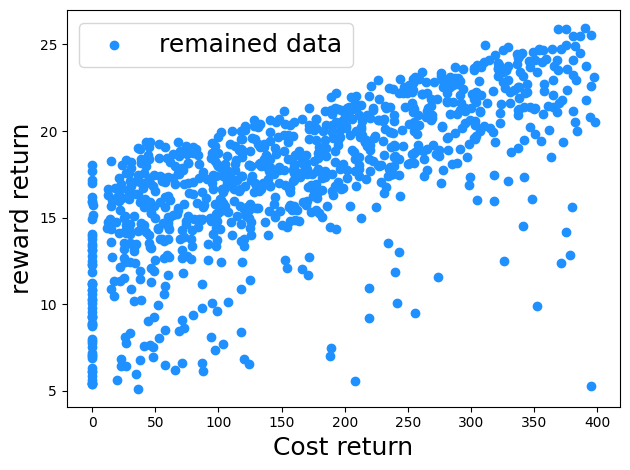

In [861]:
env, obs_dim, act_dim = get_env(task)
main_data = get_dataset_in_d4rl_format(env, trajectory_cfg, task, 1000)

Number of true negative trajectory dataset: 5
Number of false negative trajectory dataset: 0
Number of union trajectory dataset: 500
Avg union trajectory cost/reward: 166.310/17.354
Number of positive trajectory dataset: 1
Avg positive trajectory cost/reward: 0.000/18.014
Number of negative trajectory dataset: 5
Avg negative trajectory cost/reward: 304.400/14.205


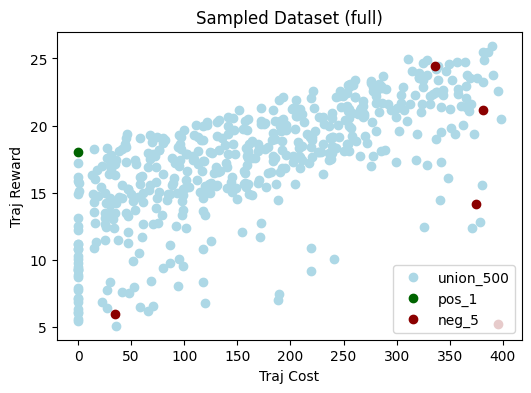

In [862]:
pos_data, neg_data, union_data = get_pos_neg_and_union_data(main_data, trajectory_cfg)

if is_norm:
    pos_data, neg_data, union_data, mu_obs, std_obs = get_normalized_data(
        pos_data, neg_data, union_data
    )

del main_data

In [876]:
hz = 200

In [877]:
data_buffer = construct_buffer((pos_data, neg_data, union_data), obs_dim, act_dim, hz, 64)

In [878]:
key, subkey = jax.random.split(key)
pos_idxs, neg_idxs, union_idxs = data_buffer.sample_idxs(data_buffer, subkey, 100)

In [879]:
def batch(i, key, curriculum_embedding_model, embedding_model):
    data = data_buffer.sample_batch(data_buffer, pos_idxs[i], neg_idxs[i], union_idxs[i])
    pos = jnp.concat([data.pos_obs, data.pos_act], axis=-1)
    neg = jnp.concat([data.neg_obs, data.neg_act], axis=-1)
    union = jnp.concat([data.union_obs, data.union_act], axis=-1)

    key1, key2, key3 = jax.random.split(key, 3)
    mix_p = jax.random.uniform(key=key1, shape=union.shape)
    runion = jax.random.permutation(key2, union, axis=0)
    random = mix_p * runion + (1 - mix_p) * union
    
    outval = jax.random.uniform(
        key3, shape=union.shape, dtype=jnp.float32, minval=-10.0, maxval=10.0
    )

    # B X embd
    zpos = curriculum_embedding_model(pos, training=False)[:, -1, :]
    zneg = curriculum_embedding_model(neg, training=False)[:, -1, :]
    zunion = curriculum_embedding_model(union, training=False)[:, -1, :]
    zrandom = curriculum_embedding_model(random, training=False)[:, -1, :]
    zoutval = curriculum_embedding_model(outval, training=False)[:, -1, :]
    zunion_ne = embedding_model(union, training=False)[:, -1, :]
    
    pos_neg = zpos @ zneg.T
    pos_union = zpos @ zunion.T
    neg_union = zneg @ zunion.T
    union_union = zunion @ zunion.T
    random_union = zrandom @ zunion.T
    out_pos = zoutval @ zpos.T
    embd_curr = zunion_ne @ zunion.T
    
    pos_neg_val = (pos_neg.min(), pos_neg.max(), pos_neg.mean(), pos_neg.std())
    pos_union_val = (pos_union.min(), pos_union.max(), pos_union.mean(), pos_union.std())
    neg_union_val = (neg_union.min(), neg_union.max(), neg_union.mean(), neg_union.std())
    union_union_val = (union_union.min(), union_union.max(), union_union.mean(), union_union.std())
    random_union_val = (random_union.min(), random_union.max(), random_union.mean(), random_union.std())
    out_pos_val = (out_pos.min(), out_pos.max(), out_pos.mean(), out_pos.std())
    embd_curr_val = (embd_curr.min(), embd_curr.max(), embd_curr.mean(), embd_curr.std())
    return (pos_neg_val, pos_union_val, neg_union_val, union_union_val, random_union_val, out_pos_val, embd_curr_val)
    

In [880]:
def plot_statistics(pos_neg_val, pos_union_val, neg_union_val, union_union_val, random_union_val, out_pos_val, embd_curr_val, title):
    # Compute statistics
    stats = {
        "pos_neg": pos_neg_val,
        "pos_union": pos_union_val,
        "neg_union": neg_union_val,
        "union_union": union_union_val,
        "random_union": random_union_val,
        "out_pos": out_pos_val,
        "embd_curr": embd_curr_val,
    }

    labels = list(stats.keys())

    mins  = np.array([v[0] for v in stats.values()])
    maxs  = np.array([v[1] for v in stats.values()])
    means = np.array([v[2] for v in stats.values()])
    stds  = np.array([v[3] for v in stats.values()])

    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(10, 6))

    # Main bars with std error bars
    ax.bar(x, means, yerr=stds, capsize=6,)

    # Mark min values
    ax.scatter(x, mins,marker="_", s=400, label="min")

    # Mark max values
    ax.scatter(x, maxs, marker="_", s=400, label="max")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20)
    ax.set_ylabel("Value")
    ax.set_title(title)

    ax.legend()

    plt.tight_layout()
    plt.show()

In [890]:
embedding_model = TransformerEmbedding(
    rngs=nnx.Rngs(params=seed, dropout=seed + 1),
    obs_dim=obs_dim,
    act_dim=act_dim,
    horizon=hz,
    embd_dim=128,
    num_attentions=2,
    do_layer_norm=True,
    do_residual=True,
)

curriculum_embedding_model = TransformerEmbedding(
    rngs=nnx.Rngs(params=seed + 42, dropout=seed + 47),
    obs_dim=obs_dim,
    act_dim=act_dim,
    horizon=hz,
    embd_dim=128,
    num_attentions=3,
    do_layer_norm=True,
    do_residual=False,
)

In [891]:
val = batch(15, key, curriculum_embedding_model, embedding_model)

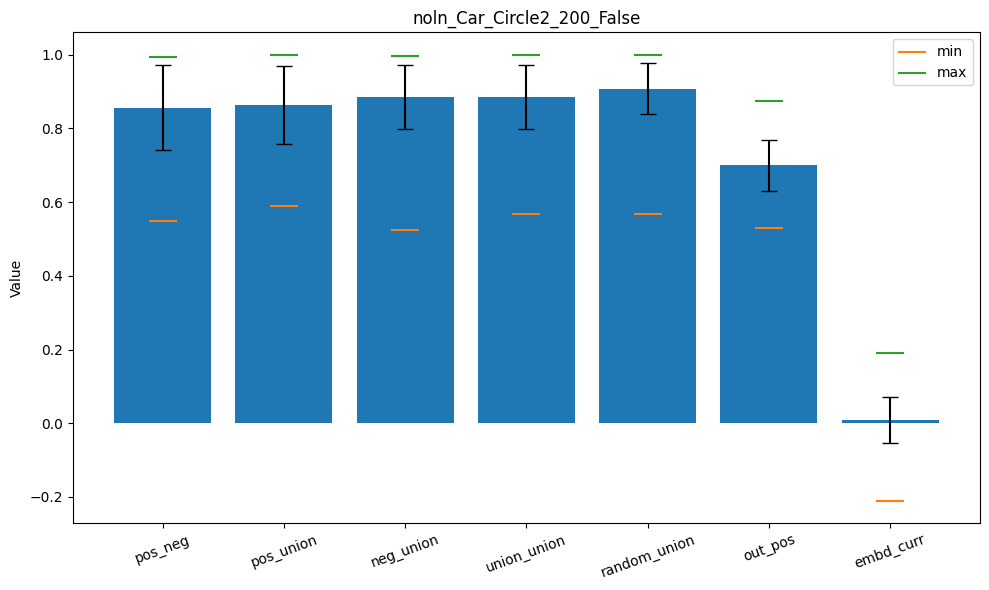

In [892]:
plot_statistics(*val, f"noln_{task_name}_{hz}_{is_norm}")

#### NN based target

In [13]:
model1 = TransformerEmbedding(
        rngs=nnx.Rngs(0), 
        obs_dim=obs_dim,
        act_dim=act_dim,
        horizon=100,
        embd_dim=embd_dim,
        num_attentions=num_attentions,
    )

model2 = TransformerEmbedding(
        rngs=nnx.Rngs(13), 
        obs_dim=obs_dim,
        act_dim=act_dim,
        horizon=100,
        embd_dim=embd_dim,
        num_attentions=3,

    )

In [14]:
key = jax.random.PRNGKey(0)
r = jax.random.normal(key=key, shape=(32, 100, obs_dim+act_dim))

In [15]:
z1 = model1(r, training=False)
z2 = model2(r, training=False)

In [16]:
jnp.einsum("ij,ij->i", z1, z2)

Array([ 0.0074787 ,  0.06002655,  0.08689655,  0.09369391,  0.16183268,
        0.09380711,  0.04966401,  0.1115236 ,  0.01988813,  0.09005217,
        0.07070477, -0.07376831,  0.02372983, -0.0107938 ,  0.16768037,
        0.01269658,  0.00111571, -0.0469263 ,  0.00951684,  0.04666883,
        0.05275911,  0.03168996,  0.05763179,  0.06597352,  0.00520258,
        0.07466348,  0.12866458,  0.14035243,  0.02181611,  0.09274537,
        0.12663719,  0.07208955], dtype=float32)

In [19]:
jnp.min(z1 @ z1.T), jnp.mean(z1 @ z1.T)

(Array(0.34987766, dtype=float32), Array(0.60247034, dtype=float32))